In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

In [5]:
path = r"C:\Users\USER\Desktop\Jupyter_Lab\UANL\SEM7\Mineria\MineriaUANL\P5\steam_limpio.csv"
data = pd.read_csv(path, encoding='latin-1')
df = data.copy()

=== MATRIZ DE CORRELACIÓN ===
                     appid   english  positive_ratings  negative_ratings  \
appid             1.000000 -0.116878         -0.070888         -0.052198   
english          -0.116878  1.000000          0.006001          0.005705   
positive_ratings -0.070888  0.006001          1.000000          0.762804   
negative_ratings -0.052198  0.005705          0.762804          1.000000   
average_playtime -0.070236  0.000338          0.157898          0.161140   
median_playtime  -0.048308 -0.003416          0.035776          0.047887   
price            -0.152112  0.007716          0.036110          0.051259   

                  average_playtime  median_playtime     price  
appid                    -0.070236        -0.048308 -0.152112  
english                   0.000338        -0.003416  0.007716  
positive_ratings          0.157898         0.035776  0.036110  
negative_ratings          0.161140         0.047887  0.051259  
average_playtime          1.000000       

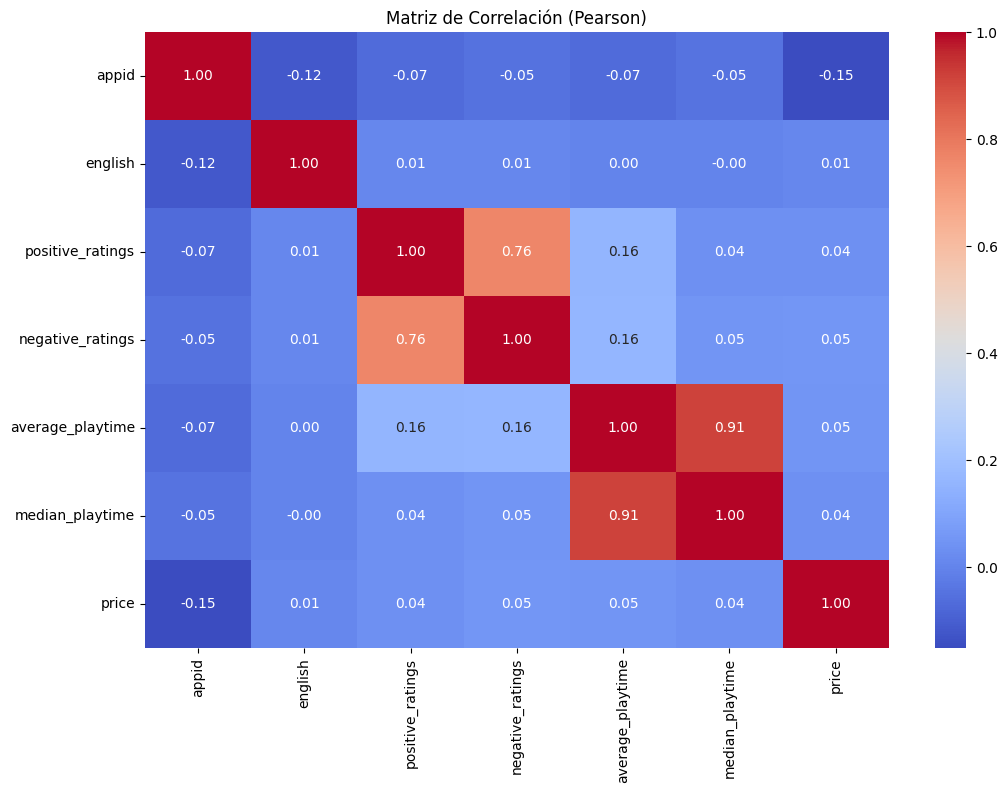

In [6]:
# Seleccionar solo las columnas numéricas
numerical_columns = df.select_dtypes(include=['int64', 'float64'])

# Calcular la matriz de correlación
correlation_matrix = numerical_columns.corr(method='pearson')

print("=== MATRIZ DE CORRELACIÓN ===")
print(correlation_matrix)

# Visualización de la matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de Correlación (Pearson)")
plt.show()

In [10]:
# Variables independientes (X) y dependientes (y)
X = df[['price']]  # Precio como variable independiente
y = df['positive_ratings']  # Calificaciones positivas como dependiente

In [11]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)

# ---------------------------------
# Resultados del Modelo
# ---------------------------------
intercept = model.intercept_
coef = model.coef_[0]
r2_train = model.score(X_train, y_train)  # R^2 en entrenamiento
r2_test = r2_score(y_test, y_pred)  # R^2 en prueba

print("=== MODELO LINEAL ===")
print(f"Intercepto (β0): {intercept:.4f}")
print(f"Pendiente (β1): {coef:.4f}")
print(f"R^2 (Entrenamiento): {r2_train:.4f}")
print(f"R^2 (Prueba): {r2_test:.4f}")

=== MODELO LINEAL ===
Intercepto (β0): 405.1606
Pendiente (β1): 79.4235
R^2 (Entrenamiento): 0.0012
R^2 (Prueba): 0.0017


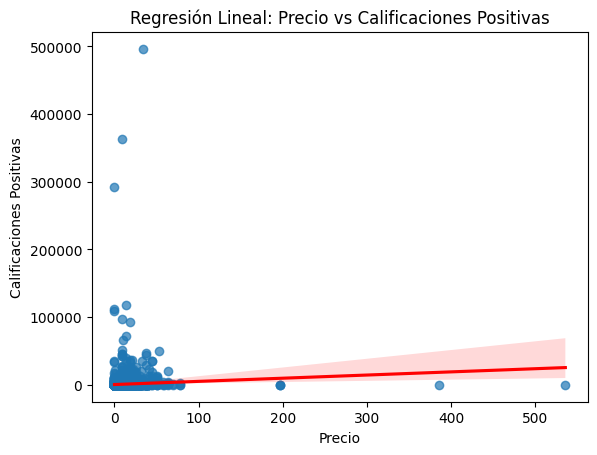

In [12]:
# Gráfico de regresión para los datos de prueba
sns.regplot(x=X_test['price'], y=y_test, line_kws={"color": "red"}, scatter_kws={"alpha": 0.7})
plt.title("Regresión Lineal: Precio vs Calificaciones Positivas")
plt.xlabel("Precio")
plt.ylabel("Calificaciones Positivas")
plt.show()

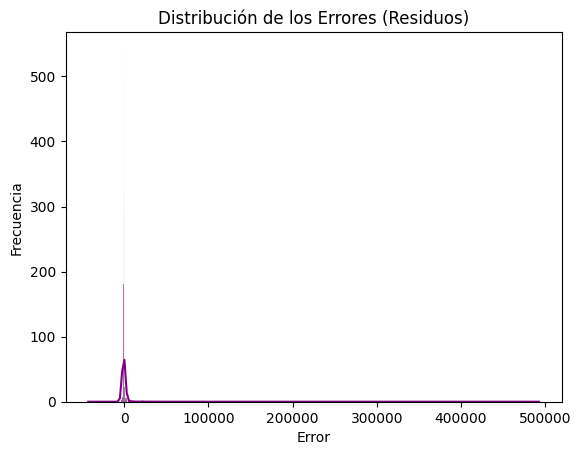

In [13]:
# Histograma de errores
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='purple')
plt.title("Distribución de los Errores (Residuos)")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()

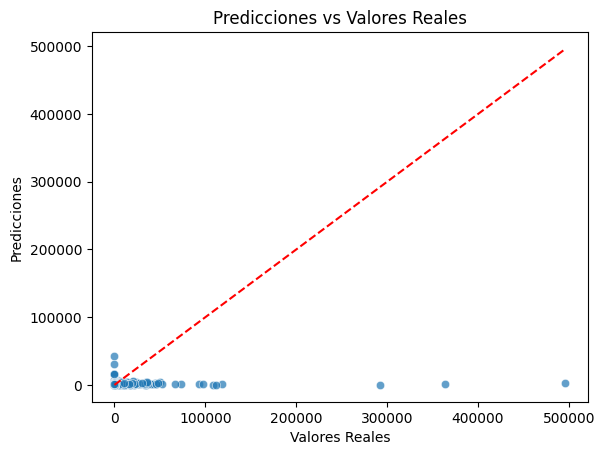

In [14]:
# Diagrama de dispersión para predicciones vs valores reales
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Predicciones vs Valores Reales")
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.show()

=== REGRESIÓN LINEAL ===
Intercepto (β0): 471.3261
Pendiente (β1): 68.5596
R^2: 0.0013


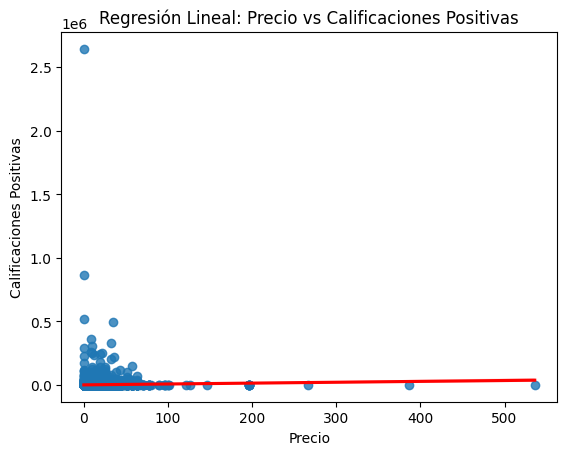

In [15]:
# Variables para el análisis
x = df['price'].values.reshape(-1, 1)
y = df['positive_ratings'].values

# ---------------------------------
# 1. Regresión Lineal
# ---------------------------------
# Crear el modelo
model = LinearRegression()
model.fit(x, y)

# Obtener coeficientes
intercept = model.intercept_
slope = model.coef_[0]

# Predicciones
y_pred = model.predict(x)

print("=== REGRESIÓN LINEAL ===")
print(f"Intercepto (β0): {intercept:.4f}")
print(f"Pendiente (β1): {slope:.4f}")
print(f"R^2: {model.score(x, y):.4f}")

# Visualización
sns.regplot(x='price', y='positive_ratings', data=df, line_kws={'color': 'red'})
plt.title("Regresión Lineal: Precio vs Calificaciones Positivas")
plt.xlabel("Precio")
plt.ylabel("Calificaciones Positivas")
plt.show()